In [1]:
!pip install ultralytics
!pip install pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 94.7 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu

In [2]:
# =========================
# Import Libraries
# =========================

import cv2
import numpy as np

from torchvision import transforms
from ultralytics import YOLO

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# =========================
# Data Preprocessing
# =========================

IMG_SIZE = 640

def preprocess_image(image_path):

    img = cv2.imread(image_path)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img / 255.0

    return img

In [4]:
# =========================
# Data Augmentation
# =========================

augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    )
])


In [5]:
# =========================
# Model Training
# =========================

model = YOLO("yolov8n.pt")

model.train(
    data="kitti.yaml",
    epochs=20,
    imgsz=640
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=kitti.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a38962a9b20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

In [7]:
# Run detection on KITTI test image
results = model.predict(
    source="/kaggle/working//datasets/kitti/images/val",
    save=True
)

for r in results:

    boxes = r.boxes

    for i in range(len(boxes)):

        x1, y1, x2, y2 = map(
            int,
            boxes.xyxy[i]
        )

        cls = int(boxes.cls[i])

        conf = float(boxes.conf[i])

        # print(
        #     "Class:", cls,
        #     "Confidence:", conf,
        #     "Box:", (x1, y1, x2, y2)
        # )


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1496 /kaggle/working/datasets/kitti/images/val/000000.png: 224x640 1 pedestrian, 41.0ms
image 2/1496 /kaggle/working/datasets/kitti/images/val/000001.png: 224x640 1 car, 1 truck, 1 cyclist, 6.2ms
image 3/1496 /kaggle/working/datasets/kitti/images/val/000012.png: 224x640 1 car, 1 van, 7.1ms
image 4/1496 /kaggle/working/datasets/kitti/images/val/000013.png: 224x640 1 car, 6.3ms
image 5/1496 /kaggle/working/datasets/kitti/images/val/000017.png: 224x

### Visualize Detection Results
We can use the `plot()` method from the YOLO results to see the bounding boxes on the actual images.

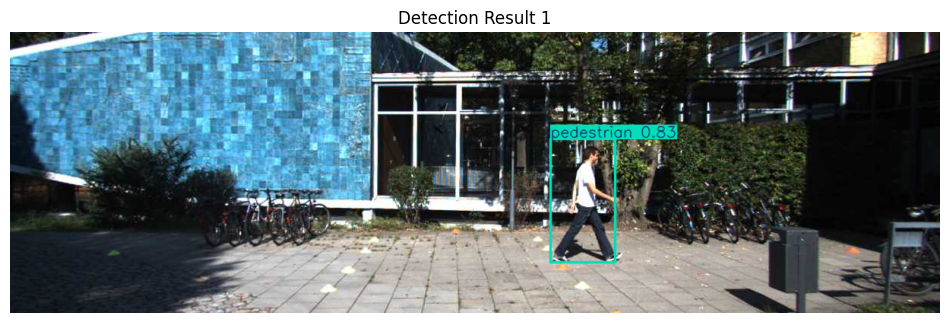

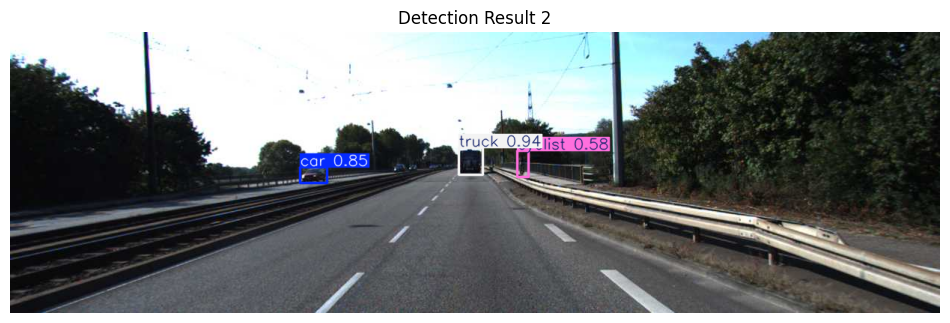

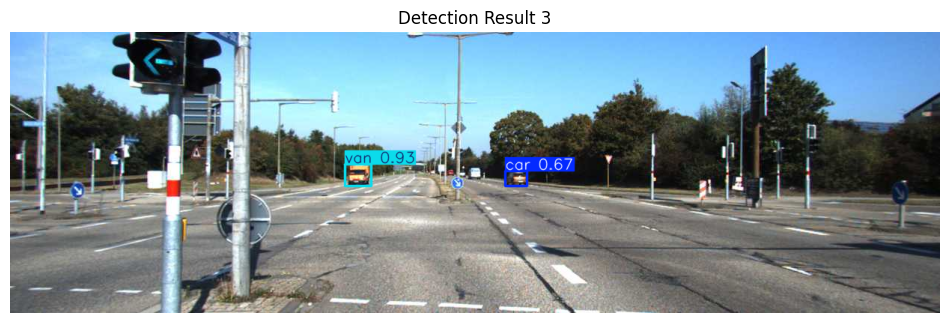

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

# Display the first few detection results
for i, r in enumerate(results[:3]):
    im_array = r.plot()
    im = Image.fromarray(im_array[..., ::-1]) # Convert BGR to RGB
    plt.figure(figsize=(12, 8))
    plt.imshow(im)
    plt.title(f"Detection Result {i+1}")
    plt.axis('off')
    plt.show()

In [9]:
def compute_iou(boxA, boxB):

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])

    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB-xA) * max(0, yB-yA)

    areaA = (boxA[2]-boxA[0]) * \
            (boxA[3]-boxA[1])

    areaB = (boxB[2]-boxB[0]) * \
            (boxB[3]-boxB[1])

    union = areaA + areaB - inter

    return inter / union


gt = [50,50,150,150]
pred = [60,60,160,160]

iou = compute_iou(gt, pred)

print("IoU =", iou)

IoU = 0.680672268907563


In [10]:
import glob
import os

def get_latest_valid_run(base_dir='/kaggle/working/runs/detect', prefix='train'):
    """Finds the most recent training directory that actually contains weights."""
    dirs = glob.glob(os.path.join(base_dir, f"{prefix}*"))
    if not dirs:
        return None

    # Sort directories by modification time, newest first
    sorted_dirs = sorted(dirs, key=os.path.getmtime, reverse=True)

    for d in sorted_dirs:
        # Check if this run has weights; if not, it likely crashed/interrupted
        if os.path.exists(os.path.join(d, 'weights/best.pt')):
            return d

    # Fallback to the newest if none have weights
    return sorted_dirs[0]

# Identify the latest valid run for use in subsequent cells
LATEST_RUN = get_latest_valid_run()
print(f"Latest valid run detected: {LATEST_RUN}")

Latest valid run detected: /kaggle/working/runs/detect/train


In [11]:
from ultralytics import YOLO

model = YOLO(LATEST_RUN+'/weights/best.pt')

metrics = model.val(
    data="/kaggle/working/datasets/kitti/kitti.yaml"
)

print("mAP@0.5 =", metrics.box.map50)
print("mAP@0.5:0.95 =", metrics.box.map)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1463.2±476.6 MB/s, size: 47.8 KB)
val: Scanning /kaggle/working/datasets/kitti/labels/val.cache... 1496 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1496/1496 522.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 11.1it/s 8.4s0.1s
                   all       1496       8128      0.827      0.691      0.782      0.522
                   car       1322       5716       0.91      0.861      0.935      0.712
                   van        419        555      0.854      0.755      0.851      0.627
                 truck        212        223      0.938      0.865      0.941      0.727
            pedestrian        377        921      0.838      0.549      0.689      0.364
        person_sitting      

In [12]:
# Automatically use the best weights from the latest run
weights_path = os.path.join(LATEST_RUN, 'weights/best.pt')
model = YOLO(weights_path)

metrics = model.val(data="kitti.yaml")

print(f"Results from: {weights_path}")
print("mAP@0.5 =", metrics.box.map50)
print("mAP@0.5:0.95 =", metrics.box.map)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1602.5±401.7 MB/s, size: 52.4 KB)
val: Scanning /kaggle/working/datasets/kitti/labels/val.cache... 1496 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1496/1496 570.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 11.4it/s 8.2s0.2s
                   all       1496       8128      0.827      0.691      0.782      0.522
                   car       1322       5716       0.91      0.861      0.935      0.712
                   van        419        555      0.854      0.755      0.851      0.627
                 truck        212        223      0.938      0.865      0.941      0.727
            pedestrian        377        921      0.838      0.549      0.689      0.364
        person_sitting      

In [13]:
import os

# Path to the training results plot
results_path = '/kaggle/working/runs/detect/train-3/results.png'

if os.path.exists(results_path):
    plt.figure(figsize=(15, 10))
    plt.imshow(Image.open(results_path))
    plt.axis('off')
    plt.title("Training Metrics (Loss and mAP)")
    plt.show()
else:
    print("Results plot not found. Check the save directory.")

Results plot not found. Check the save directory.


### Detailed Training Artifacts
Let's visualize the training data batches, confusion matrices, and validation results to better understand the model's performance.

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import os

artifact_files = [
    '/kaggle/working/runs/detect/train-3/train_batch1.jpg',
    '/kaggle/working/runs/detect/train-3/train_batch2.jpg',
    '/kaggle/working/runs/detect/train-3/confusion_matrix.png',
    '/kaggle/working/runs/detect/train-3/confusion_matrix_normalized.png',
    '/kaggle/working/runs/detect/train-3/BoxF1_curve.png',
    '/kaggle/working/runs/detect/train-3/val_batch2_pred.jpg'
]

for img_path in artifact_files:
    if os.path.exists(img_path):
        plt.figure(figsize=(12, 10))
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(os.path.basename(img_path))
        plt.axis('off')
        plt.show()
    else:
        print(f'File not found: {img_path}')

File not found: /kaggle/working/runs/detect/train-3/train_batch1.jpg
File not found: /kaggle/working/runs/detect/train-3/train_batch2.jpg
File not found: /kaggle/working/runs/detect/train-3/confusion_matrix.png
File not found: /kaggle/working/runs/detect/train-3/confusion_matrix_normalized.png
File not found: /kaggle/working/runs/detect/train-3/BoxF1_curve.png
File not found: /kaggle/working/runs/detect/train-3/val_batch2_pred.jpg


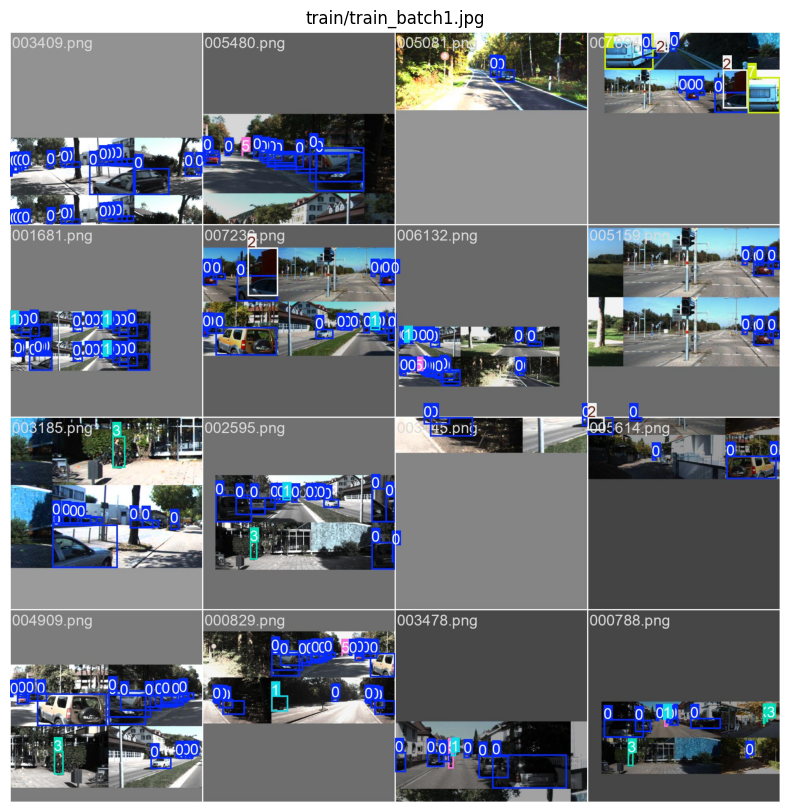

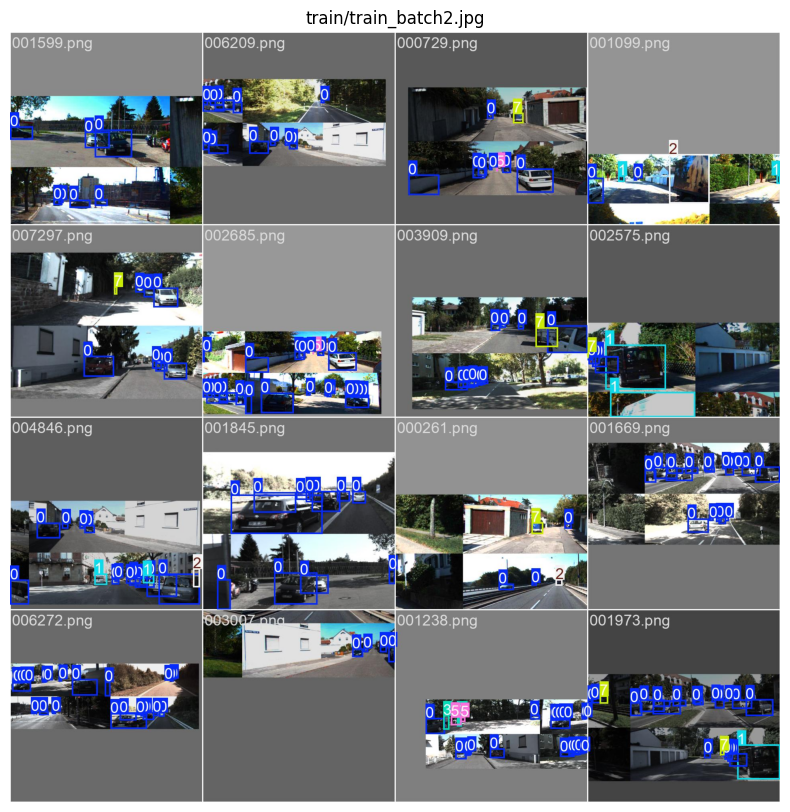

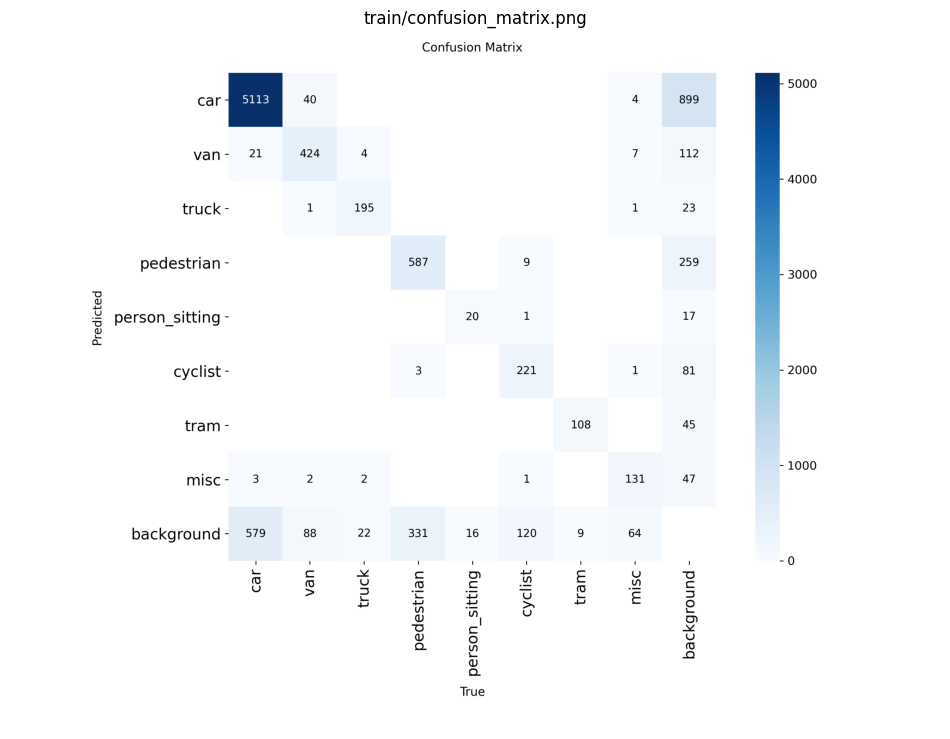

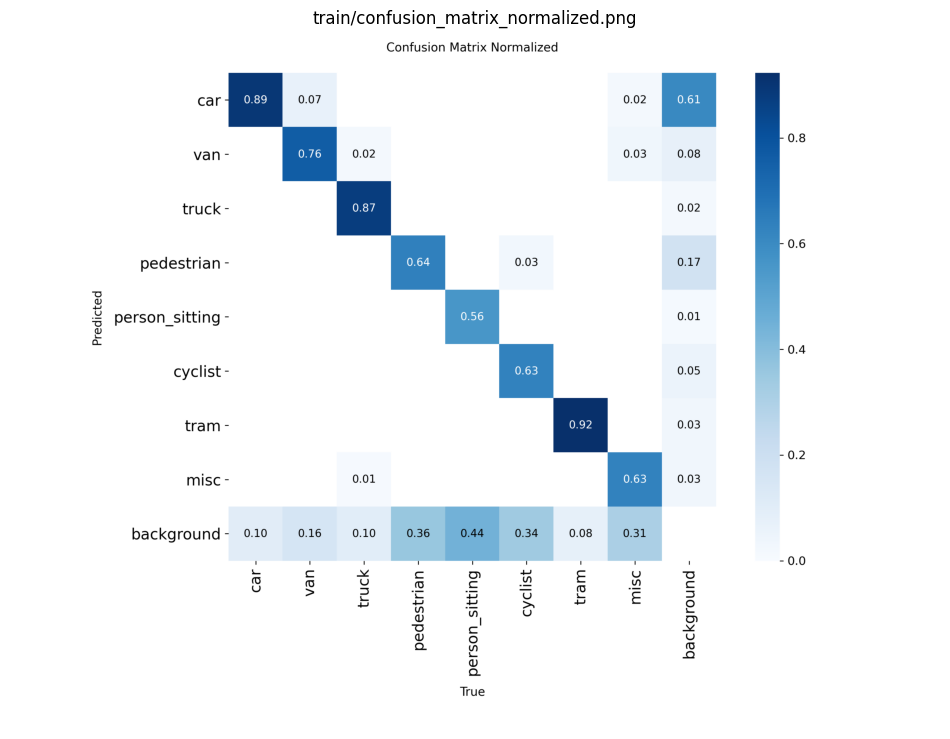

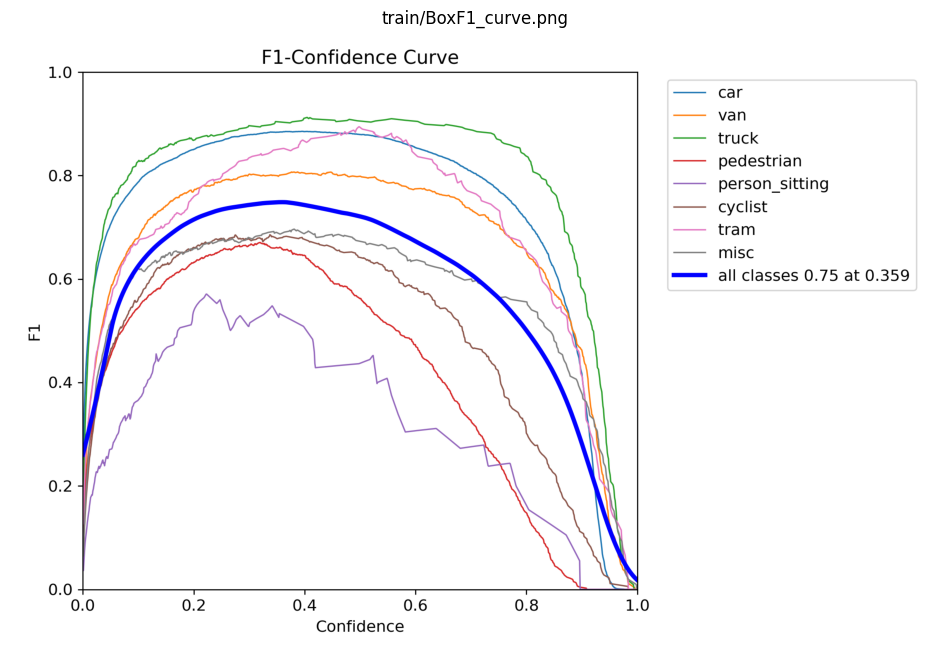

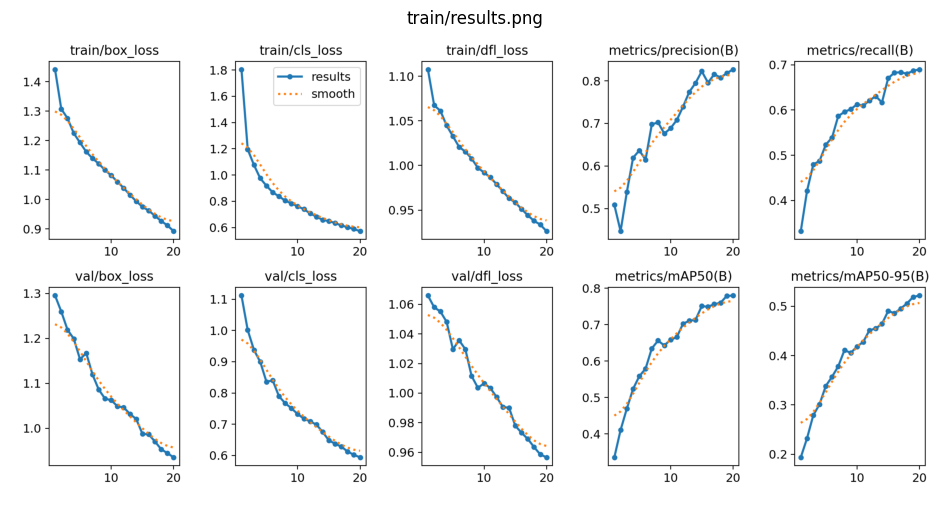

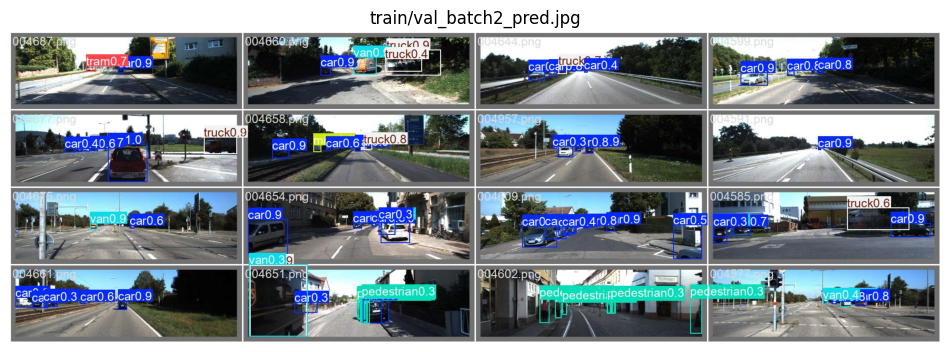

In [15]:
# Automatically visualize artifacts from the latest run
artifact_names = [
    'train_batch1.jpg',
    'train_batch2.jpg',
    'confusion_matrix.png',
    'confusion_matrix_normalized.png',
    'BoxF1_curve.png',
    'results.png',
    'val_batch2_pred.jpg'
]

for name in artifact_names:
    img_path = os.path.join(LATEST_RUN, name)
    if os.path.exists(img_path):
        plt.figure(figsize=(12, 10))
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"{os.path.basename(LATEST_RUN)}/{name}")
        plt.axis('off')
        plt.show()
    else:
        print(f'File not found: {img_path}')